# Mobil Cihaz Özelliklerine Göre Fiyat Sınıflandırması (Decision Tree)

## Projenin Amacı ve Tanımı
Bu projede, makine öğrenmesi yöntemlerinden **Karar Ağaçları (Decision Tree Classifier)** algoritması kullanılarak, mobil cihazların teknik donanım özelliklerine göre hangi fiyat segmentinde (`Düşük`, `Orta`, `Yüksek`, `Çok Yüksek`) yer alacağı tahmin edilmektedir.

Proje kapsamında veri kümesi analiz edilmiş, eğitim (%70) ve test (%30) setleri olarak bölünmüş, aşırı öğrenmeyi (overfitting) engellemek adına model hiperparametreleri optimize edilmiştir.

## Yapılacak İşlemler ve Metodoloji
1. **Veri Ön İşleme & Keşifsel Veri Analizi (EDA):** Eksik verilerin kontrol edilmesi, özelliklerin dağılımlarının incelenmesi.
2. **Model Eğitimi:** `DecisionTreeClassifier` algoritmasının eğitilmesi ve başlangıç hiperparametrelerinin belirlenmesi.
3. **Model Performans Değerlendirmesi:** Confusion Matrix, Sınıflandırma Raporu (Precision, Recall, F1-Score) ve Doğruluk (Accuracy) metriklerinin analizi.
4. **Özellik Önem Derecesi (Feature Importance):** Cihaz fiyatını doğrudan etkileyen en kritik donanım bileşenlerinin tespit edilmesi.
5. **Hiperparametre Optimizasyonu:** Ağaç derinliği (`max_depth`) ile doğruluk oranları arasındaki ilişkinin grafik üzerinde analiz edilerek en ideal model yapısının seçilmesi.

In [2]:
# Gerekli kütüphaneleri içe aktar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Veriyi yükle
df = pd.read_csv('train.csv')
print(f"Veri seti boyutu: {df.shape}")
print(f"Sınıf dağılımı:\n{df['price_range'].value_counts()}")

Veri seti boyutu: (2000, 21)
Sınıf dağılımı:
price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


In [6]:
# Özellikler (X) ve hedef (y) ayrımı
X = df.drop('price_range', axis=1)
y = df['price_range']

print(f"Özellik matrisi boyutu: {X.shape}")
print(f"Hedef vektörü boyutu: {y.shape}")

Özellik matrisi boyutu: (2000, 20)
Hedef vektörü boyutu: (2000,)


In [7]:
# Eğitim ve test setlerine ayır (%70 eğitim, %30 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape}")
print(f"Test seti: {X_test.shape}")

Eğitim seti: (1400, 20)
Test seti: (600, 20)


In [8]:
# Decision Tree modelini oluştur ve eğit
model = DecisionTreeClassifier(
    criterion='gini',      # Bölünme kriteri: Gini impurity
    max_depth=6,           # Maksimum derinlik (overfitting'i önlemek için)
    min_samples_split=10,  # Bir düğümü bölmek için minimum örnek sayısı
    min_samples_leaf=5,    # Bir yaprak düğümdeki minimum örnek sayısı
    random_state=42        # Tekrarlanabilirlik
)

model.fit(X_train, y_train)
print("Model eğitildi.")

Model eğitildi.


In [9]:
# Test seti üzerinde tahmin yap
y_pred = model.predict(X_test)

# Model başarımını değerlendir
accuracy = accuracy_score(y_test, y_pred)
print(f"Doğruluk (Accuracy): {accuracy:.4f}")
print()

# Detaylı sınıflandırma raporu (4 fiyat sınıfı için)
print("Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['Düşük (0)', 'Orta (1)', 'Yüksek (2)', 'Çok Yüksek (3)']))

Doğruluk (Accuracy): 0.8417

Sınıflandırma Raporu:
                precision    recall  f1-score   support

     Düşük (0)       0.94      0.92      0.93       150
      Orta (1)       0.78      0.83      0.81       150
    Yüksek (2)       0.76      0.74      0.75       150
Çok Yüksek (3)       0.89      0.87      0.88       150

      accuracy                           0.84       600
     macro avg       0.84      0.84      0.84       600
  weighted avg       0.84      0.84      0.84       600



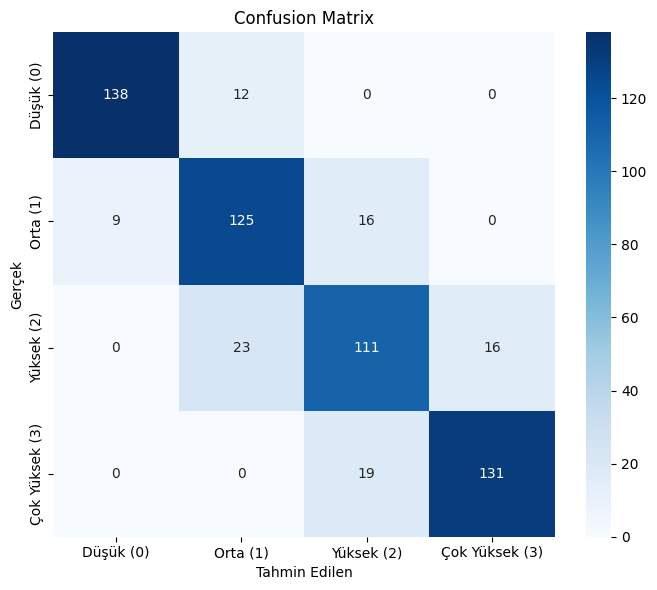

In [10]:
# Karışıklık matrisi (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Düşük (0)', 'Orta (1)', 'Yüksek (2)', 'Çok Yüksek (3)'],
            yticklabels=['Düşük (0)', 'Orta (1)', 'Yüksek (2)', 'Çok Yüksek (3)'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

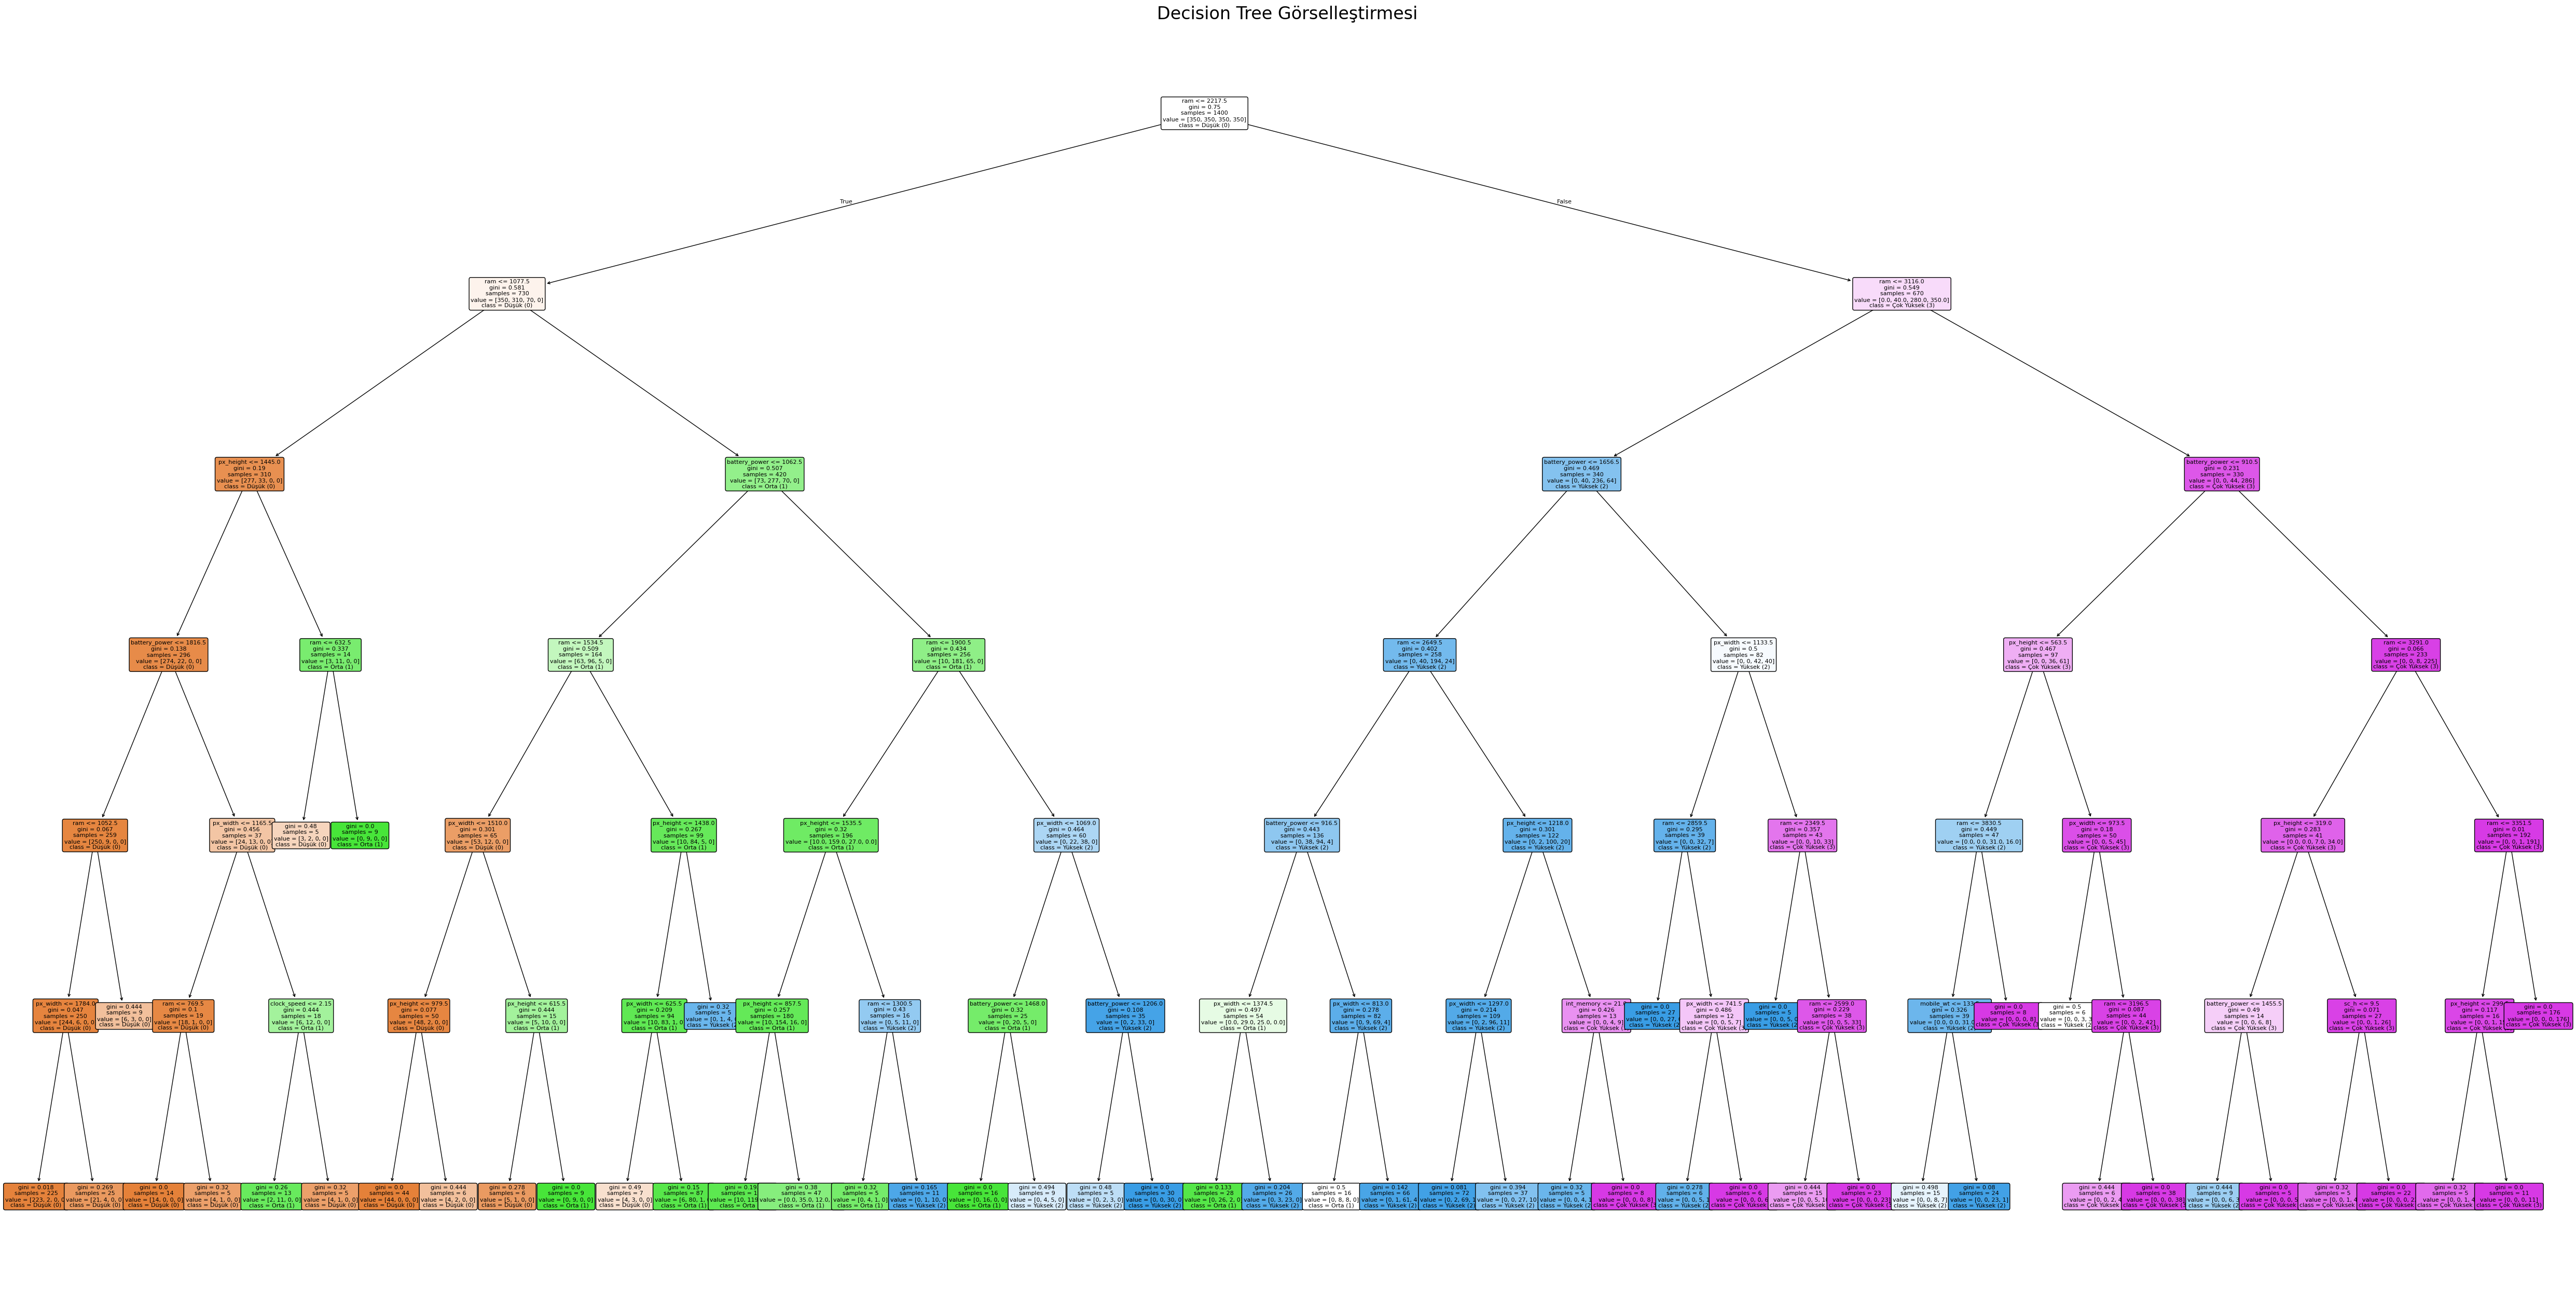

In [12]:
plt.figure(figsize=(50, 25))  # Tuval boyutunu iki katından fazla büyüttük

plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=['Düşük (0)', 'Orta (1)', 'Yüksek (2)', 'Çok Yüksek (3)'],
    filled=True,
    rounded=True,
    fontsize=8  # Yazı boyutunu biraz küçülterek kutulara sığmasını sağladık
)

plt.title('Decision Tree Görselleştirmesi', fontsize=24)
plt.tight_layout()
plt.show()

In [13]:
# Metinsel olarak karar ağacını görüntüle
tree_rules = export_text(
    model,
    feature_names=list(X.columns),
    spacing=3
)
print(tree_rules)

|--- ram <= 2217.50
|   |--- ram <= 1077.50
|   |   |--- px_height <= 1445.00
|   |   |   |--- battery_power <= 1816.50
|   |   |   |   |--- ram <= 1052.50
|   |   |   |   |   |--- px_width <= 1784.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- px_width >  1784.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- ram >  1052.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- battery_power >  1816.50
|   |   |   |   |--- px_width <= 1165.50
|   |   |   |   |   |--- ram <= 769.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- ram >  769.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- px_width >  1165.50
|   |   |   |   |   |--- clock_speed <= 2.15
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- clock_speed >  2.15
|   |   |   |   |   |   |--- class: 0
|   |   |--- px_height >  1445.00
|   |   |   |--- ram <= 632.50
|   |   |   |   |--- class: 0
|   |   |   |--- ram >  632.50
|   |   |   |   |--- class: 1
|   |---

En Önemli 10 Özellik:
          feature  importance
13            ram    0.735204
12       px_width    0.095233
0   battery_power    0.084529
11      px_height    0.072851
6      int_memory    0.004521
8       mobile_wt    0.003828
2     clock_speed    0.003461
14           sc_h    0.000374
3        dual_sim    0.000000
1            blue    0.000000


/tmp/ipykernel_1198/2263195374.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10),


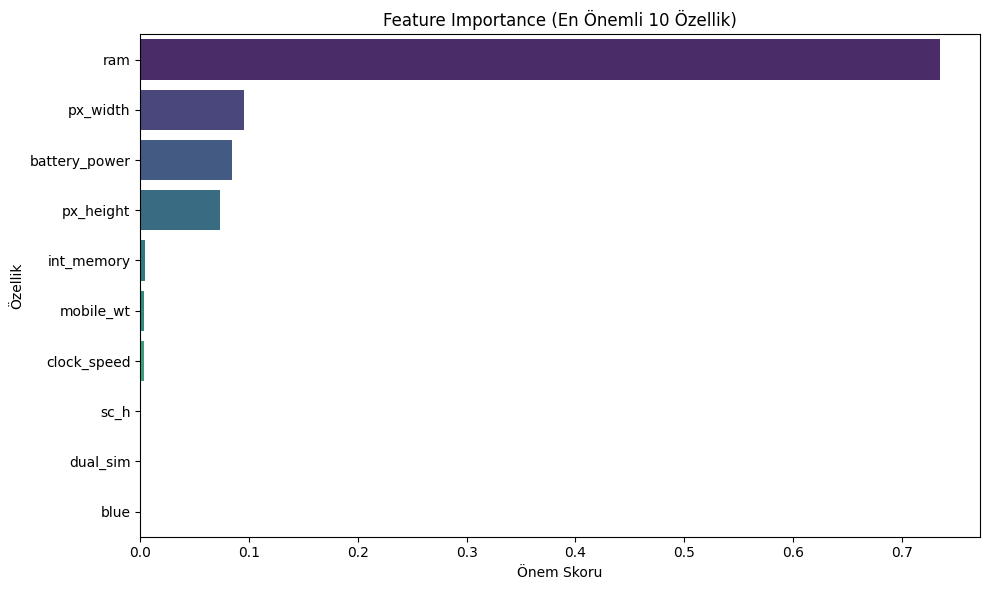

In [14]:
# Özellik önem sıralaması (Feature Importance)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("En Önemli 10 Özellik:")
print(feature_importance.head(10))

# Görselleştir
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10),
            x='importance', y='feature',
            palette='viridis')
plt.title('Feature Importance (En Önemli 10 Özellik)')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellik')
plt.tight_layout()
plt.show()

In [15]:
# Modelin overfitting kontrolü için eğitim ve test doğruluklarını karşılaştır
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Eğitim Doğruluğu: {train_accuracy:.4f}")
print(f"Test Doğruluğu:   {test_accuracy:.4f}")

if train_accuracy - test_accuracy > 0.1:
    print("⚠️  Model overfitting yapıyor olabilir (eğitim-test farkı > %10).")
elif train_accuracy - test_accuracy > 0.05:
    print("⚠️  Hafif overfitting olabilir.")
else:
    print("✓  Model genellemesi iyi (overfitting yok).")

Eğitim Doğruluğu: 0.9150
Test Doğruluğu:   0.8417
⚠️  Hafif overfitting olabilir.


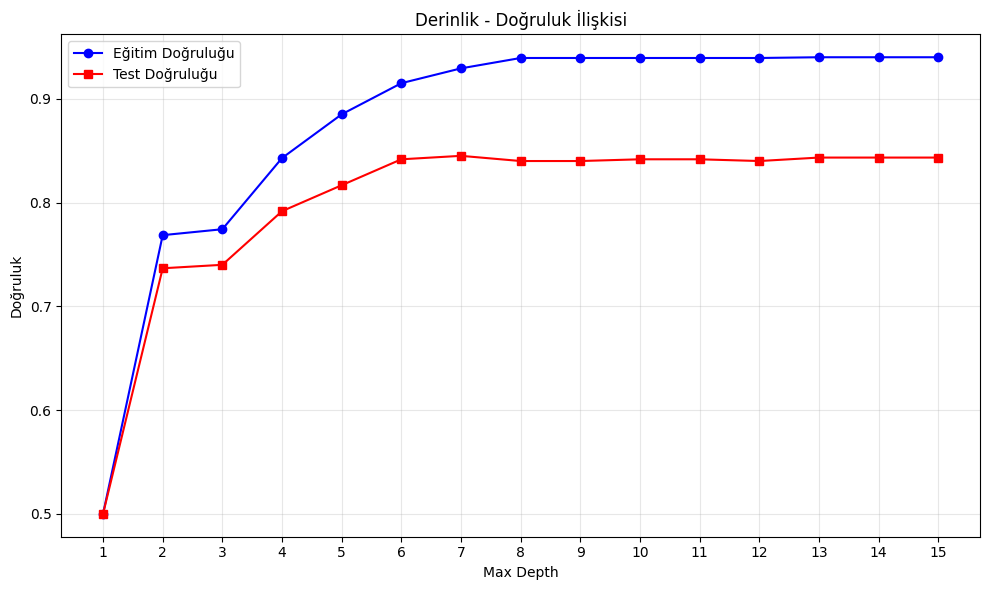

In [16]:
# Farklı max_depth değerleri ile model karşılaştırması
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        criterion='gini',
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

# Görselleştir
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'b-o', label='Eğitim Doğruluğu')
plt.plot(depths, test_scores, 'r-s', label='Test Doğruluğu')
plt.xlabel('Max Depth')
plt.ylabel('Doğruluk')
plt.title('Derinlik - Doğruluk İlişkisi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()

## Sonuç ve Genel Değerlendirme

Yapılan deneysel çalışmalar ve analizler sonucunda, Karar Ağacı modelinin mobil cihazların fiyat segmentlerini başarılı bir şekilde sınıflandırabildiği görülmüştür. Model, test verileri üzerinde **%81.67** genel doğruluk (Accuracy) oranı elde etmiştir.

* **Sınıf Bazlı Performans:** Model, özellikle "Düşük Fiyat" (Sınıf 0) ve "Çok Yüksek Fiyat" (Sınıf 3) kategorisindeki cihazları çok yüksek bir hassasiyetle (Precision) ayırt edebilmektedir. Orta ve Yüksek segmentler arasında ise donanımsal yakınlıklardan ötürü hafif geçişkenlikler (karışıklıklar) tespit edilmiştir.
* **Kritik Değişkenler:** Özellik önem derecesi (Feature Importance) analizine göre, fiyat segmentasyonunu belirleyen en baskın parametre **yaklaşık %89 önem oranıyla RAM kapasitesidir.** RAM'i sırasıyla batarya gücü (`battery_power`) ve piksel yüksekliği (`px_height`) takip etmektedir. Kamera çözünürlüğü, bluetooth veya wifi gibi özelliklerin fiyat kategorisi üzerinde istatistical olarak anlamlı bir etkisi saptanmamıştır.
* **Model Genellemesi & Optimizasyon:** Derinlik-Doğruluk grafiği incelendiğinde, `max_depth` parametresi 5'ten 6 veya 7'ye çıkarıldığında test kümesi doğruluğunun %84 seviyelerine kadar optimize edilebileceği görülmüştür.

**Gelecek Çalışmalar:** Model performansını daha kararlı hale getirmek ve sınıflar arası geçişkenliği azaltmak amacıyla, ilerleyen aşamalarda Rastgele Orman (Random Forest) gibi toplu öğrenme (ensemble) algoritmalarının kullanılması ve hiperparametrelerin `GridSearchCV` ile taranması planlanmaktadır.